# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

In this assignment, you will explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches. You will work with the EuroSAT dataset to implement and evaluate various classification models, from simple SVMs to complex deep learning architectures.

## Submission Guidelines

**All assignments must be completed in groups of 2-3 students.** One member of the group should submit on behalf of everyone, making sure to include all group members' names at the top of the notebook.

Your assignment should be submitted via a pull request to the main branch of this repository. Please make sure it is in the `assignments` subdirectory, titled `eurosat.ipynb`, with any additional files included in a subfolder named `eurosat_files`. Additionally:
- Your notebook must contain the complete assignment instructions, followed by the relevant code chunks
- Your notebook must include group members' names and submission date
- All code must be well-formatted with appropriate code chunks (no overly long code blocks)
- All code must be linted and formatted using [`ruff`](https://docs.astral.sh/ruff/) before submission



## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

Visit [the EuroSAT data description page](https://github.com/phelber/eurosat) and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.


In [ ]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image handling
from PIL import Image
from skimage.color import rgb2gray

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# tensorflow / keras
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Activation
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
# load data
DATA_DIR = "./EuroSAT_RGB"
IMG_SIZE = 64
x = []
y = []
class_names = []


for label, class_name in enumerate(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    
    if not os.path.isdir(class_path):
        continue
        
    class_names.append(class_name)
    
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)
        
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img)
            
            x.append(img_array)
            y.append(label)
            
        except Exception as e:
            print(f"Skipping {img_path}: {e}")



### EDA

In [ ]:
# shape exploration
x = np.array(x)
y = np.array(y)


print("Shape of x:", x.shape)
print("Shape of y:", y.shape)
print("Classes:", class_names)

In [ ]:
# class counts
counts = pd.Series(y).value_counts().sort_index()

class_dist = pd.DataFrame({
    "Class": class_names,
    "Count": counts.values
})

print(class_dist)

In [ ]:
# class counts histogram

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (EuroSAT)")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
# class images

plt.figure(figsize =(14,6))
for i, class_name in enumerate(class_names):
    idx = np.random.choice(np.where(y == i)[0])

    plt.subplot(2,5,i + 1)
    plt.imshow(x[idx])
    plt.title(class_name)
    plt.axis('off')

plt.suptitle("Example Images for each Class")
plt.tight_layout()
plt.show()

In [ ]:
# flatten images into 2D arrays
N, H, W, C = x.shape
x_rgb = x.reshape(N, H * W * C).astype(np.float32) / 255.0   # (N, 64*64*3)

print(x_rgb.shape)

In [ ]:
# train test split

idx = np.arange(N)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.4,
    stratify=y,
    random_state=42
)

x_rgb_train = x_rgb[train_idx]
x_rgb_test = x_rgb[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("\n--- RGB Train/Test Split ---")
print("x_rgb_train:", x_rgb_train.shape)
print("x_rgb_test: ", x_rgb_test.shape)
print("y_train:    ", y_train.shape)
print("y_test:     ", y_test.shape)

In [ ]:
# grayscale conversion and train test split

x_gray_img = rgb2gray(x)

print("Grayscale image shape:", x_gray_img.shape)

N, H, W = x_gray_img.shape
x_gray = x_gray_img.reshape(N, H * W)

print("Flattened grayscale shape:", x_gray.shape)

x_gray_train = x_gray[train_idx]
x_gray_test = x_gray[test_idx]

print("\nGrayscale Train/Test Split")
print("x_gray_train:", x_gray_train.shape)
print("x_gray_test: ", x_gray_test.shape)
print("y_train:     ", y_train.shape)
print("y_test:      ", y_test.shape)


### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.


In [ ]:
# augmentation: three separate subsets, each with a different transform
rng = np.random.default_rng(42)

# shuffle and split into 3 subsets of 25% each
shuffled = rng.permutation(len(x))
n_sub = int(len(x) * 0.25)

hflip_idx = shuffled[:n_sub]
vflip_idx  = shuffled[n_sub:2 * n_sub]
rot90_idx  = shuffled[2 * n_sub:3 * n_sub]

x_hflip = np.flip(x[hflip_idx], axis=2)
x_vflip = np.flip(x[vflip_idx], axis=1)
x_rot90 = np.rot90(x[rot90_idx], k=1, axes=(1, 2))

x_aug = np.concatenate([x, x_hflip, x_vflip, x_rot90], axis=0)
y_aug = np.concatenate([y, y[hflip_idx], y[vflip_idx], y[rot90_idx]], axis=0)

print(f"Original:        {len(x):,}")
print(f"+ hflip subset:  {len(x_hflip):,}")
print(f"+ vflip subset:  {len(x_vflip):,}")
print(f"+ rot90 subset:  {len(x_rot90):,}")
print(f"Augmented total: {len(x_aug):,}  (~{len(x_aug)/len(x):.1f}x original)")
print(f"x_aug shape: {x_aug.shape}")

In [ ]:
# plot 3 random images from augmented dataset
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
rand_idx = np.random.choice(len(x_aug), 3, replace=False)
for i, idx in enumerate(rand_idx):
    axes[i].imshow(x_aug[idx])
    axes[i].set_title(class_names[y_aug[idx]])
    axes[i].axis("off")
plt.suptitle("Random Images from Augmented Dataset")
plt.tight_layout()
plt.show()

In [ ]:
# class distribution histogram after augmentation
counts_aug = pd.Series(y_aug).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts_aug)
plt.xticks(rotation=45)
plt.title("Class Distribution after Augmentation")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [ ]:
# redo flatten + grayscale + train/test split using augmented data
# NOTE: overwrites the 1.1 split variables
N_aug = len(x_aug)

x_rgb = x_aug.reshape(N_aug, IMG_SIZE * IMG_SIZE * 3).astype(np.float32) / 255.0

x_gray_img = rgb2gray(x_aug)
x_gray = x_gray_img.reshape(N_aug, IMG_SIZE * IMG_SIZE).astype(np.float32)

aug_idx = np.arange(N_aug)
train_idx, test_idx = train_test_split(
    aug_idx, test_size=0.4, stratify=y_aug, random_state=42
)

x_rgb_train  = x_rgb[train_idx]
x_rgb_test   = x_rgb[test_idx]
x_gray_train = x_gray[train_idx]
x_gray_test  = x_gray[test_idx]
y_train      = y_aug[train_idx]
y_test       = y_aug[test_idx]

print("--- Augmented Train/Test Split ---")
print(f"x_rgb_train:  {x_rgb_train.shape}")
print(f"x_rgb_test:   {x_rgb_test.shape}")
print(f"x_gray_train: {x_gray_train.shape}")
print(f"x_gray_test:  {x_gray_test.shape}")
print(f"y_train:      {y_train.shape}")
print(f"y_test:       {y_test.shape}")


## 2. Traditional Machine Learning

For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.

### 2.1 Binary Support Vector Machine (Joey)

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

In [13]:
# Subseting augmented training data

label_map = {name: i for i, name in enumerate(class_names)}

target_classes = ["Forest", "Residential", "Industrial"]
target_labels = [label_map[name] for name in target_classes]


train_mask_sub = np.isin(y_train_aug, target_labels)
x_gray_train_sub = x_gray_train_aug[train_mask_sub]
y_train_sub = y_train_aug[train_mask_sub]

# subset untouched test data
test_mask_sub = np.isin(y_test, target_labels)
x_gray_test_sub = x_gray_test[test_mask_sub]
y_test_sub = y_test[test_mask_sub]
x_img_test_sub = x_test_img[test_mask_sub]

print("Subset shapes:")
print("x_gray_train_sub:", x_gray_train_sub.shape)
print("x_gray_test_sub: ", x_gray_test_sub.shape)
print("y_train_sub:     ", y_train_sub.shape)
print("y_test_sub:      ", y_test_sub.shape)
print("x_img_test_sub:  ", x_img_test_sub.shape)

Subset shapes:
x_gray_train_sub: (8928, 4096)
x_gray_test_sub:  (3400, 4096)
y_train_sub:      (8928,)
y_test_sub:       (3400,)
x_img_test_sub:   (3400, 64, 64, 3)


In [14]:
# Subset Class Distribution

train_counts_sub = pd.Series(y_train_sub).value_counts().sort_index()
test_counts_sub = pd.Series(y_test_sub).value_counts().sort_index()

train_dist_sub = pd.DataFrame({
    "Class": [class_names[i] for i in train_counts_sub.index],
    "Train Count": train_counts_sub.values
})

test_dist_sub = pd.DataFrame({
    "Class": [class_names[i] for i in test_counts_sub.index],
    "Test Count": test_counts_sub.values
})

print("Training subset distribution:")
print(train_dist_sub)

print("\nTest subset distribution:")
print(test_dist_sub)

Training subset distribution:
         Class  Train Count
0       Forest         3146
1   Industrial         2612
2  Residential         3170

Test subset distribution:
         Class  Test Count
0       Forest        1200
1   Industrial        1000
2  Residential        1200


In [15]:
# Binary Classification pairs

pairs = [
    ("Forest", "Residential"),
    ("Forest", "Industrial"),
    ("Residential", "Industrial")
]

print("Binary classifiers to run:")
for pair in pairs:
    print(pair)

Binary classifiers to run:
('Forest', 'Residential')
('Forest', 'Industrial')
('Residential', 'Industrial')


In [16]:
# train binary svms and store results

results = {}

for class_a, class_b in pairs:
    label_a = label_map[class_a]
    label_b = label_map[class_b]

    # subset training set for this pair
    train_mask = np.isin(y_train_sub, [label_a, label_b])
    X_train_pair = x_gray_train_sub[train_mask]
    y_train_pair = y_train_sub[train_mask]

    # subset test set for this pair
    test_mask = np.isin(y_test_sub, [label_a, label_b])
    X_test_pair = x_gray_test_sub[test_mask]
    y_test_pair = y_test_sub[test_mask]
    img_test_pair = x_img_test_sub[test_mask]

    # binary encode: class_a = 0, class_b = 1
    y_train_bin = (y_train_pair == label_b).astype(int)
    y_test_bin = (y_test_pair == label_b).astype(int)

    svm = SVC(kernel="linear", probability=True, random_state=42)
    svm.fit(X_train_pair, y_train_bin)

    y_pred = svm.predict(X_test_pair)
    y_score = svm.predict_proba(X_test_pair)[:, 1]

    acc = accuracy_score(y_test_bin, y_pred)
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)

    results[(class_a, class_b)] = {
        "model": svm,
        "accuracy": acc,
        "auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "y_test_bin": y_test_bin,
        "y_pred": y_pred,
        "img_test_pair": img_test_pair
    }

In [17]:
# AUC Accuracy

print("Binary Linear SVM Results")
print("-" * 50)

for (class_a, class_b), res in results.items():
    print(f"{class_a} vs {class_b}")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(f"AUC:      {res['auc']:.4f}")
    print("-" * 50)

Binary Linear SVM Results
--------------------------------------------------
Forest vs Residential
Accuracy: 0.9546
AUC:      0.9956
--------------------------------------------------
Forest vs Industrial
Accuracy: 0.9950
AUC:      1.0000
--------------------------------------------------
Residential vs Industrial
Accuracy: 0.7327
AUC:      0.7847
--------------------------------------------------


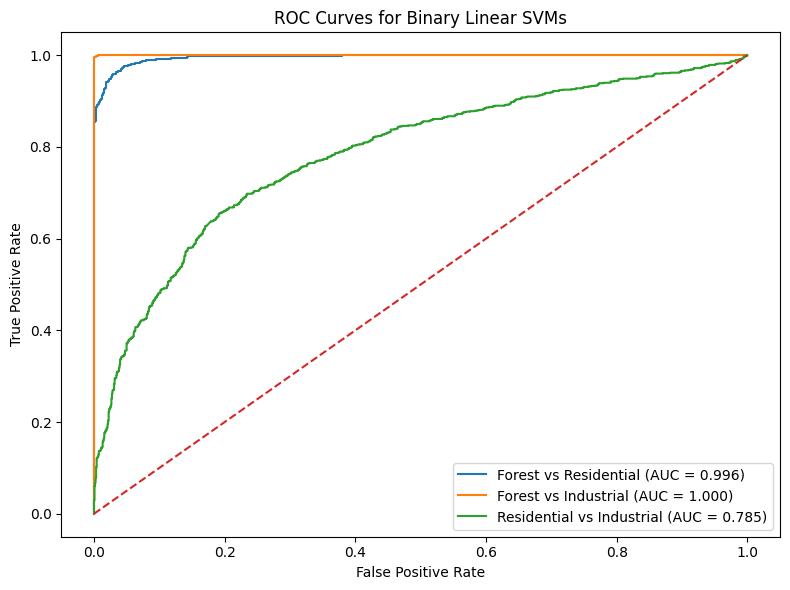

In [18]:
# ROC Curves

plt.figure(figsize=(8, 6))

for (class_a, class_b), res in results.items():
    plt.plot(
        res["fpr"],
        res["tpr"],
        label=f"{class_a} vs {class_b} (AUC = {res['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Binary Linear SVMs")
plt.legend()
plt.tight_layout()
plt.show()

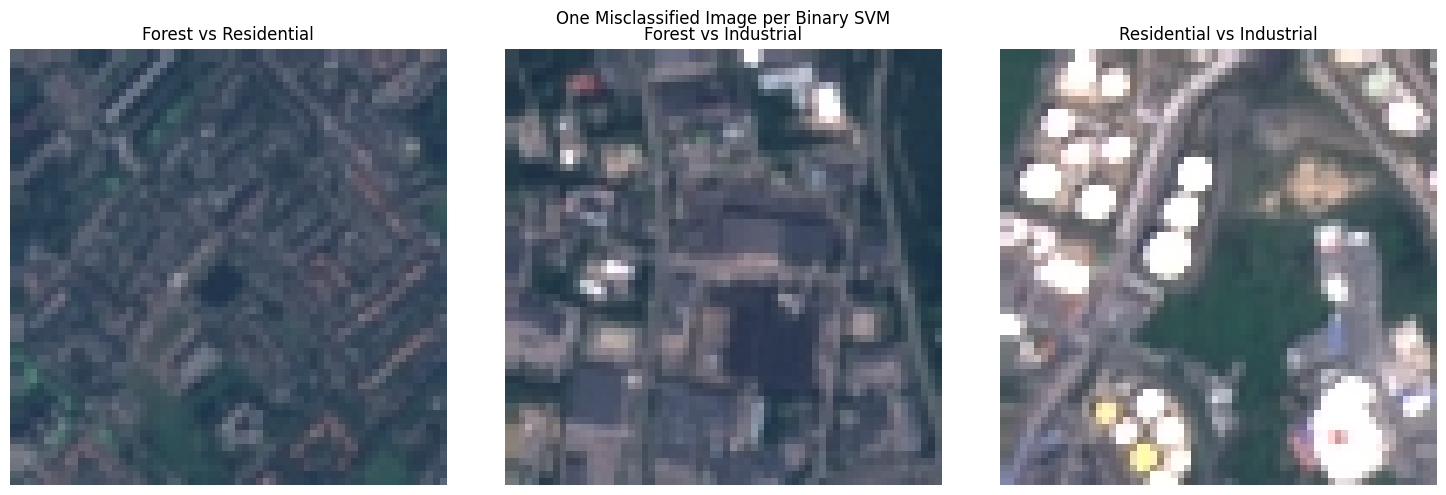

In [19]:
# missclassified images

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ((class_a, class_b), res) in zip(axes, results.items()):
    mis_idx = np.where(res["y_pred"] != res["y_test_bin"])[0]

    if len(mis_idx) == 0:
        ax.text(
            0.5, 0.5,
            f"No misclassifications\nfor {class_a} vs {class_b}",
            ha="center",
            va="center",
            fontsize=11
        )
        ax.axis("off")
        continue

    i = mis_idx[0]

    img = res["img_test_pair"][i]
    true_bin = res["y_test_bin"][i]
    pred_bin = res["y_pred"][i]

    true_label = class_b if true_bin == 1 else class_a
    pred_label = class_b if pred_bin == 1 else class_a

    ax.imshow(img)
    ax.set_title(f"{class_a} vs {class_b}")
    ax.set_xlabel(f"Predicted: {pred_label}\nTrue: {true_label}")
    ax.axis("off")

plt.suptitle("One Misclassified Image per Binary SVM")
plt.tight_layout()
plt.show()

#### Binary SVM Reflection and Notes

Three binary linear SVM classifiers were trained on grayscale pixel features to distinguish between Forest, Residential, and Industrial land cover type. The models achieved very high performance for Forest vs. Industrial and Forest vs. Residential (AUC ≈ 1.0 and 0.995), indicating these classes are highly separable, while performance was notably lower for Residential vs. Industrial (AUC ≈ 0.76), reflecting greater visual similarity between those classes. Overall, the results show that simple linear models can effectively distinguish natural versus built environments, but differentiating urban land types is more difficult.

### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

In [20]:
# map original label ids to 0, 1, 2 for multi class svm
subset_to_idx = {label_map[name]: i for i, name in enumerate(target_classes)}
idx_to_class = {i: name for i, name in enumerate(target_classes)}

y_test_multi = np.array([subset_to_idx[y] for y in y_test_sub])

print("Target class mapping:")
for original_label, new_label in subset_to_idx.items():
    print(f"{class_names[original_label]} -> {new_label}")

Target class mapping:
Forest -> 0
Residential -> 1
Industrial -> 2


In [21]:
# applying binary svms to 3 class subset

n_test = x_gray_test_sub.shape[0]
n_classes = len(target_classes)

# stores hard votes for majority voting
vote_counts = np.zeros((n_test, n_classes), dtype=int)

# stores summed probability support for each class
score_matrix = np.zeros((n_test, n_classes), dtype=float)

for (class_a, class_b), res in results.items():
    model = res["model"]

    # run this binary classifier on the full 3-class test subset
    pred_bin = model.predict(x_gray_test_sub)
    prob_bin = model.predict_proba(x_gray_test_sub)

    idx_a = target_classes.index(class_a)
    idx_b = target_classes.index(class_b)

    # hard vote: 0 -> class_a, 1 -> class_b
    pred_class = np.where(pred_bin == 0, idx_a, idx_b)

    for i in range(n_test):
        vote_counts[i, pred_class[i]] += 1

    # probability support:
    # prob_bin[:, 0] corresponds to class_a
    # prob_bin[:, 1] corresponds to class_b
    score_matrix[:, idx_a] += prob_bin[:, 0]
    score_matrix[:, idx_b] += prob_bin[:, 1]

In [22]:
# multiclass prediction by majority vote

y_pred_multi = np.argmax(vote_counts, axis=1)

multi_acc = accuracy_score(y_test_multi, y_pred_multi)

print("Multiclass Majority-Vote SVM Accuracy")
print("-" * 40)
print(f"Accuracy: {multi_acc:.4f}")

Multiclass Majority-Vote SVM Accuracy
----------------------------------------
Accuracy: 0.7944


In [23]:
# multiclass roc and auc

# binarize true labels for one-vs-rest ROC calculation
y_test_bin_multi = label_binarize(y_test_multi, classes=[0, 1, 2])

fpr_multi = {}
tpr_multi = {}
roc_auc_multi = {}

for i in range(n_classes):
    fpr_multi[i], tpr_multi[i], _ = roc_curve(y_test_bin_multi[:, i], score_matrix[:, i])
    roc_auc_multi[i] = auc(fpr_multi[i], tpr_multi[i])

# micro-average ROC/AUC
fpr_multi["micro"], tpr_multi["micro"], _ = roc_curve(
    y_test_bin_multi.ravel(),
    score_matrix.ravel()
)
roc_auc_multi["micro"] = auc(fpr_multi["micro"], tpr_multi["micro"])

print("\nMulticlass One-vs-Rest AUCs")
print("-" * 40)
for i, class_name in enumerate(target_classes):
    print(f"{class_name}: {roc_auc_multi[i]:.4f}")
print(f"Micro-average AUC: {roc_auc_multi['micro']:.4f}")


Multiclass One-vs-Rest AUCs
----------------------------------------
Forest: 0.9979
Residential: 0.8711
Industrial: 0.9130
Micro-average AUC: 0.9464


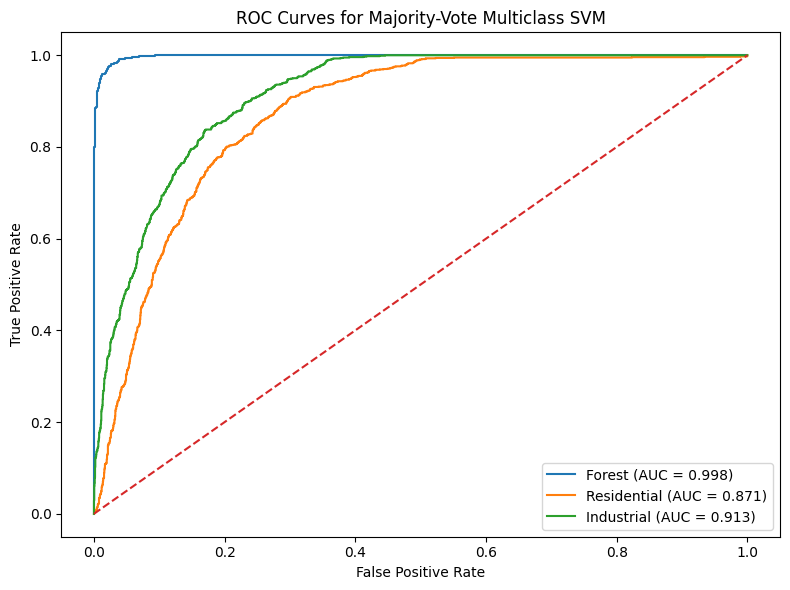

In [24]:
# multiclass roc curves

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(target_classes):
    plt.plot(
        fpr_multi[i],
        tpr_multi[i],
        label=f"{class_name} (AUC = {roc_auc_multi[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Majority-Vote Multiclass SVM")
plt.legend()
plt.tight_layout()
plt.show()

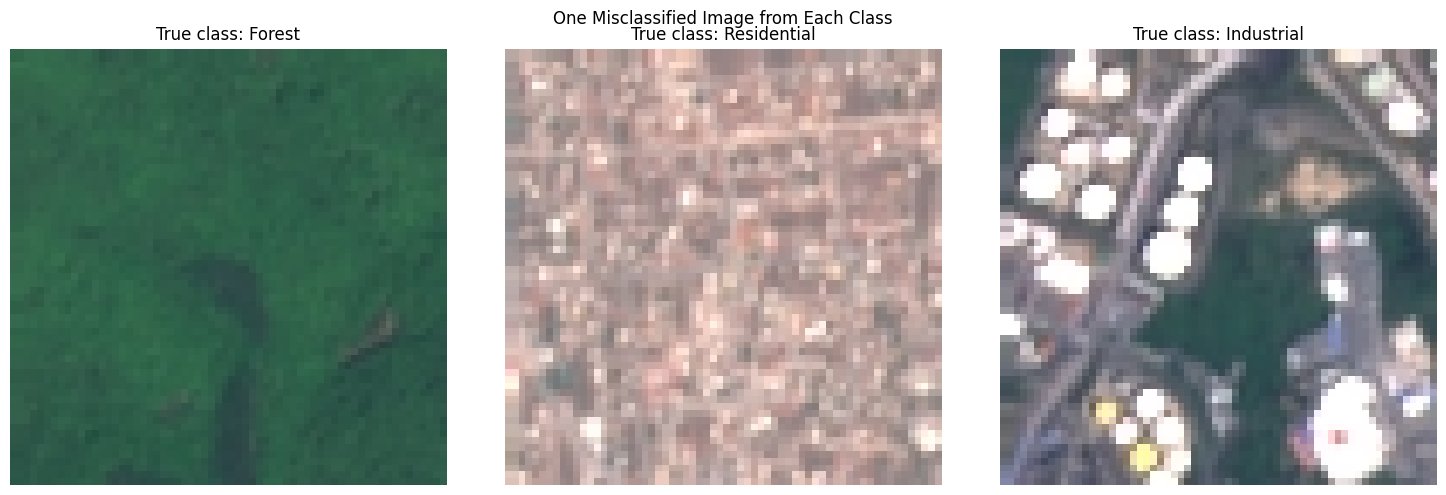

In [25]:
# misclassified images from each true class

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, class_idx in zip(axes, range(n_classes)):
    mis_idx = np.where((y_test_multi == class_idx) & (y_pred_multi != y_test_multi))[0]

    true_class_name = idx_to_class[class_idx]

    if len(mis_idx) == 0:
        ax.text(
            0.5, 0.5,
            f"No misclassified\n{true_class_name} images",
            ha="center",
            va="center",
            fontsize=11
        )
        ax.axis("off")
        continue

    i = mis_idx[0]

    img = x_img_test_sub[i]
    true_label = idx_to_class[y_test_multi[i]]
    pred_label = idx_to_class[y_pred_multi[i]]

    ax.imshow(img)
    ax.set_title(f"True class: {true_label}")
    ax.set_xlabel(f"Predicted: {pred_label}\nTrue: {true_label}")
    ax.axis("off")

plt.suptitle("One Misclassified Image from Each Class")
plt.tight_layout()
plt.show()

#### Multiclass Majority Vote SVM Reflection

The multiclass SVM combines the three binary classifiers by having each model vote on the class of a test image, and the final prediction is the class that receives the majority of votes. This approach achieved an overall accuracy of 0.80, with a strong micro-average AUC of 0.95, indicating good overall classification performance.

Compared to the binary results, performance remains very high for Forest (AUC ≈ 0.998), reflecting its clear separability, while Residential and Industrial show lower AUCs (≈ 0.87 and 0.91), consistent with the earlier binary result where Residential vs Industrial was the most difficult classification. Overall, the multiclass model preserves the strong performance for easily separable classes but sees reduced accuracy due to confusion between similar urban land uses.

### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.

In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_gray_train_sub, y_train_sub)

y_pred_rf = rf.predict(x_gray_test_sub)
rf_acc = accuracy_score(y_test_sub, y_pred_rf)
print(f'Random Forest Test Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')

Random Forest Test Accuracy: 0.9082 (90.82%)


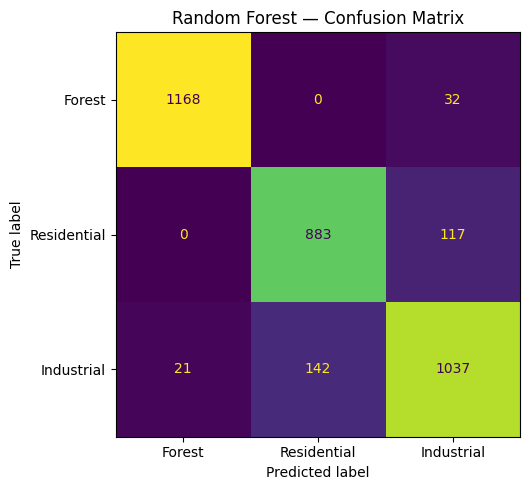

              precision    recall  f1-score   support

      Forest       0.98      0.97      0.98      1200
 Residential       0.86      0.88      0.87      1000
  Industrial       0.87      0.86      0.87      1200

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



In [27]:
# Confusion matrix
target_class_names = [class_names[label_map[c]] for c in target_classes]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_sub,
    y_pred_rf,
    display_labels=target_class_names,
    ax=ax,
    colorbar=False
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test_sub, y_pred_rf, target_names=target_class_names))

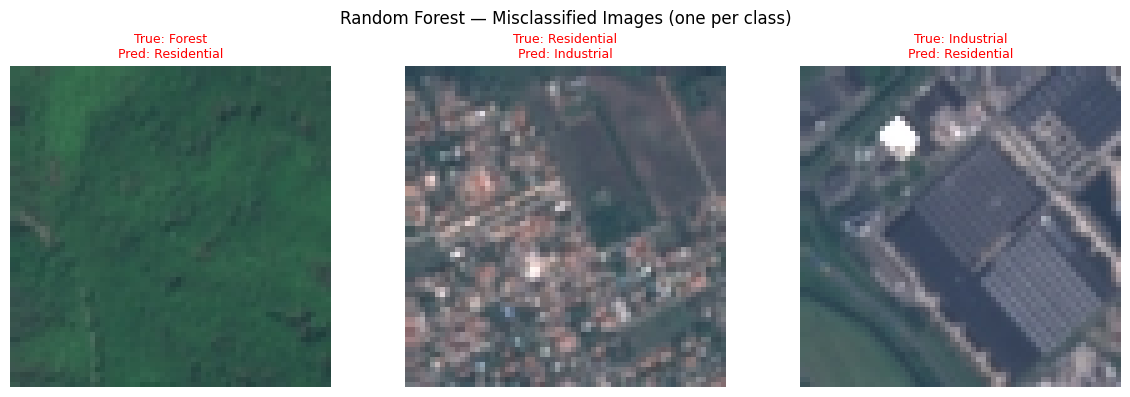

In [28]:
# Misclassified image from each class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, class_name in zip(axes, target_classes):
    label = label_map[class_name]
    class_mask = y_test_sub == label
    mis_idx = np.where(class_mask & (y_pred_rf != y_test_sub))[0]

    if len(mis_idx) == 0:
        ax.text(0.5, 0.5, f'No misclassifications\nfor {class_name}',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue

    idx = mis_idx[0]
    pred_name = class_names[y_pred_rf[idx]]
    true_name = class_names[y_test_sub[idx]]

    ax.imshow(x_img_test_sub[idx])
    ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=9, color='red')
    ax.axis('off')

plt.suptitle('Random Forest — Misclassified Images (one per class)')
plt.tight_layout()
plt.show()

#### Multiclass Random Forest Reflection

Random Forest's power comes from being able to build many decision trees on subsets of the data, and then making a decision with majority vote. This is different from the previous sections of SVM, where decisions are made across 3 binary classifiers. RF resulted in better accuracy than SVM, most likely because of RF being able to capture multiple boundaries in the pixel space.
The confusion matrix shows that RF performed the least accurate between Industrial and Residential. 


## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

### 3.1 Greyscale Images 

For this section, use the same greyscale images that you used in the traditional machine learning section.

#### 3.1.1 Single-Layer Neural Network (Angel)

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)



In [ ]:
# Imports separated to diminish merge conflicts
from tensorflow.keras.utils import to_categorical   # Allows us to one-hot encode our labels
from tensorflow.keras.models import Sequential      # Allows us to create a stack of layers
from tensorflow.keras.layers import Dense           # Allows us to add fully connected layers to our models
from tensorflow.keras.utils import plot_model       # Allows use to visualize the architecture of the models
from tensorflow.keras.layers import Dropout         # Allows us to add dropout layers
from IPython.display import Image as IPImage        # Allows more control over displaying images

In [ ]:
# Preprocessing for all models
num_classes = len(class_names)

y_train_encoded = to_categorical(y_train_aug, num_classes) # Hot encode augmented training labels so crossentropy loss can be used
y_test_encoded  = to_categorical(y_test,  num_classes)

In [ ]:
# Building Model 1: Single-Layer Neural Network
model1 = Sequential()
model1.add(Dense(num_classes, activation='softmax', # Output layer of probabilities suited for multi-class classification
    input_shape=(x_gray_train.shape[1],)))

model1.compile(optimizer='adam', 
              loss='categorical_crossentropy', # Enables calculation of loss for multi-class classification
              metrics=['accuracy'])

model1.summary()


In [ ]:
# Visualize architecture of Model 1
plot_model(model1, show_shapes=True, show_layer_names=True, dpi=90)
                                                            # dpi controls the resolution, 90 makes the plot more readable

In [ ]:
# Fit Model 1
history1 = model1.fit(x_gray_train, y_train_encoded,
                    epochs= 5,                 # Regardless of the epoch and batch size, the model will overfit: 
                    batch_size= 256,           # Accuracy > validation accuracy and loss < validation loss 
                    verbose=0,                 # Suppress training output
                    validation_data=(x_gray_test, y_test_encoded))

# Evaluate Model 1
score1 = model1.evaluate(x_gray_test, y_test_encoded, verbose=0)
print(f'Model 1 Accuracy: {score1[1]:.4f}')     # Accuracy will generally stay low regardless of the epoch and batch size
print(f'Model 1 Loss:     {score1[0]:.4f}')     # Loss is pretty high, indicating the model isn't generalizing well to the test set

#### 3.1.2 Two-Layer Neural Network

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?


In [ ]:
# Building Model 2: Two-Layer Neural Network
model2 = model2 = Sequential()
model2.add(Dense(256, activation='relu', input_shape=(x_gray_train.shape[1],))) # Creates additional hidden layer
model2.add(Dense(num_classes, activation='softmax'))


model2.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model2.summary()

In [ ]:
# Visualize architecture of Model 2
plot_model(model2, show_shapes=True, show_layer_names=True, dpi=90)

In [ ]:
# Fit Model 2
history2 = model2.fit(x_gray_train, y_train_encoded, 
                    epochs=10,                  # More epochs benefitted Model 2 more than Model 1
                    batch_size=256,              
                    verbose=0,                  
                    validation_data=(x_gray_test, y_test_encoded))

# Evaluate Model 2
score2 = model2.evaluate(x_gray_test, y_test_encoded, verbose=0)
print(f'Model 2 Accuracy:   {score2[1]:.4f}')      # Hidden layer reduces overfitting as accuracy ~ validation accuracy and loss ~ validation loss
print(f'Model 2 Loss:       {score2[0]:.4f}')      # Accuracy is about 10% higher than Model 1, but still not great     

#### 3.1.3 Four-Layer Neural Network with Dropout

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

In [ ]:
# Building Model 3: Four-Layer Neural Network with Dropout
model3 = Sequential()
model3.add(Dense(512, activation='relu', input_shape=(x_gray_train.shape[1],)))
model3.add(Dropout(0.2))
model3.add(Dense(256, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(num_classes, activation='softmax'))


model3.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model3.summary()

In [ ]:
# Visualize architecture of Model 3
plot_model(model3, show_shapes=True, show_layer_names=True, dpi=90)

In [ ]:
# Fit Model 3
history3 = model3.fit(x_gray_train, y_train_encoded, 
                    epochs=5,         # Smaller epochs helped reduce overfitting         
                    batch_size=256,   
                    verbose=0,                  
                    validation_data=(x_gray_test, y_test_encoded))

# Evaluate Model 3
score3 = model3.evaluate(x_gray_test, y_test_encoded, verbose=0)
print(f'Model 3 Accuracy:   {score3[1]:.4f}')      
print(f'Model 3 Loss:       {score3[0]:.4f}')    

#### 3.1.4 Model Comparison and Ensemble

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Model 3 had the most parameters to learn. Model 2 had 25 times as many parameters as Model 1 and Model 3 had 55 times more. Model 2 benefitted from having more epochs while Model 3 benefitted from less. Model 2 can be considered better for parsimony but Model 3, although more complex, could be considered better for requiring less epochs.

#### 3.1.4 Model Comparison and Ensemble (Continued)
Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

In [ ]:
# Collect predictions
y_true_all = []
y_pred_all = []

pred1 = model1.predict(x_gray_test)
pred2 = model2.predict(x_gray_test)
pred3 = model3.predict(x_gray_test)

# Average The three models' predicted probabilities 
ensemble_pred = (pred1 + pred2 + pred3) / 3

# Convert to class labels then extend
y_pred_all.extend(np.argmax(ensemble_pred, axis=1))         # Get predicted class labels from the highest probabilities
y_true_all.extend(np.argmax(y_test_encoded, axis=1))        # Get true class labels from the one-hot encoded labels

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Accuracy
ensemble_accuracy = accuracy_score(y_true_all, y_pred_all)      
print(f'Ensemble Accuracy: {ensemble_accuracy:.4f}')

I implemented a soft‑voting ensemble by averaging the predicted probabilities from the three neural networks. All three neural network models used a softmax output layer, which produces a probability of the model's confidence in each class. By averaging their predictions, the ensemble stabilizes the variance as the errors made by one model can be compensated by the others since the information it recieves is more nuanced.

### 3.2 RGB Images

For this section, use the original RGB images.

#### 3.2.1 CNN Model (Sujan)

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

#### 3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?


In [79]:
# Advanced model: CNN + BatchNorm + Dropout + on-the-fly augmentation (inspired by our week10 lab)
def build_advanced_model(input_shape, num_classes):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), input_shape=input_shape),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D(2, 2),

        # Block 2
        Conv2D(64, (3, 3)),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D(2, 2),

        # Block 3
        Conv2D(128, (3, 3)),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.25),

        # Dense head
        Flatten(),
        Dense(256),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ], name="Advanced_CNN_EuroSAT")
    return model

model_advanced = build_advanced_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=num_classes
)
model_advanced.summary()


Model: "Advanced_CNN_EuroSAT"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 batch_normalization_24 (Ba  (None, 62, 62, 32)        128       
 tchNormalization)                                               
                                                                 
 activation_24 (Activation)  (None, 62, 62, 32)        0         
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 31, 31, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_23 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 batch_normalization_25 (Ba  (None, 29, 29, 64

In [80]:
# On-the-fly augmentation (data already normalized to [0,1])
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_cnn_train)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

model_advanced.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_advanced = model_advanced.fit(
    datagen.flow(x_cnn_train, y_cnn_train, batch_size=64),
    steps_per_epoch=len(x_cnn_train) // 64,
    epochs=40,
    validation_data=(x_cnn_test, y_cnn_test),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
442/442 [==============================] - 13s 28ms/step - loss: 0.9131 - accuracy: 0.6813 - val_loss: 2.0537 - val_accuracy: 0.3904 - lr: 0.0010
Epoch 2/40
442/442 [==============================] - 12s 26ms/step - loss: 0.6351 - accuracy: 0.7781 - val_loss: 1.5489 - val_accuracy: 0.5737 - lr: 0.0010
Epoch 3/40
442/442 [==============================] - 12s 27ms/step - loss: 0.5466 - accuracy: 0.8081 - val_loss: 1.4628 - val_accuracy: 0.6176 - lr: 0.0010
Epoch 4/40
442/442 [==============================] - 12s 27ms/step - loss: 0.4727 - accuracy: 0.8360 - val_loss: 2.7552 - val_accuracy: 0.4091 - lr: 0.0010
Epoch 5/40
442/442 [==============================] - 12s 27ms/step - loss: 0.4304 - accuracy: 0.8483 - val_loss: 1.5810 - val_accuracy: 0.5783 - lr: 0.0010
Epoch 6/40
442/442 [==============================] - 12s 27ms/step - loss: 0.3907 - accuracy: 0.8647 - val_loss: 2.0074 - val_accuracy: 0.6027 - lr: 0.0010
Epoch 7/40
442/442 [==============================] - 12s 

In [81]:
score_advanced = model_advanced.evaluate(x_cnn_test, y_cnn_test, verbose=0)
print(f"Advanced Model Accuracy: {score_advanced[1]:.4f} ({score_advanced[1]*100:.2f}%)")
print(f"CNN Baseline Accuracy:   0.8485 (84.85%)")

Advanced Model Accuracy: 0.9574 (95.74%)
CNN Baseline Accuracy:   0.8485 (84.85%)


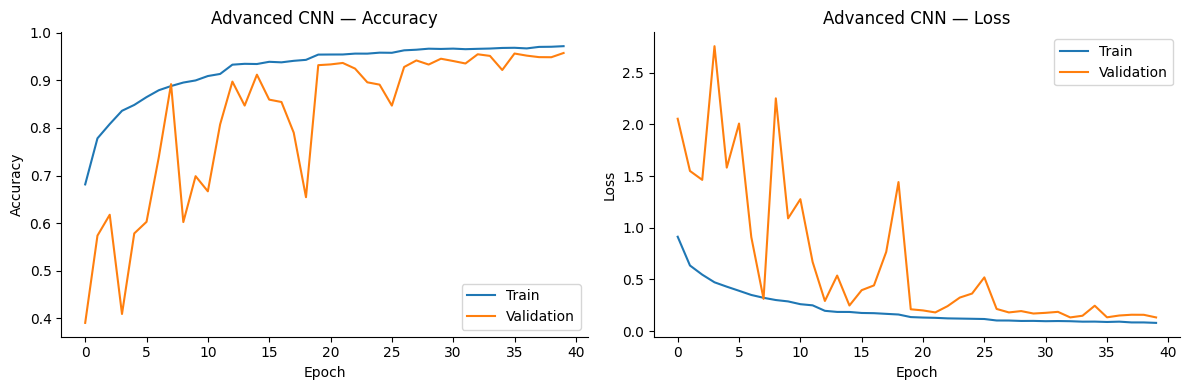

In [83]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_advanced.history["accuracy"], label="Train")
axes[0].plot(history_advanced.history["val_accuracy"], label="Validation")
axes[0].set_title("Advanced CNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(history_advanced.history["loss"], label="Train")
axes[1].plot(history_advanced.history["val_loss"], label="Validation")
axes[1].set_title("Advanced CNN — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

338/338 [==============================] - 1s 3ms/step


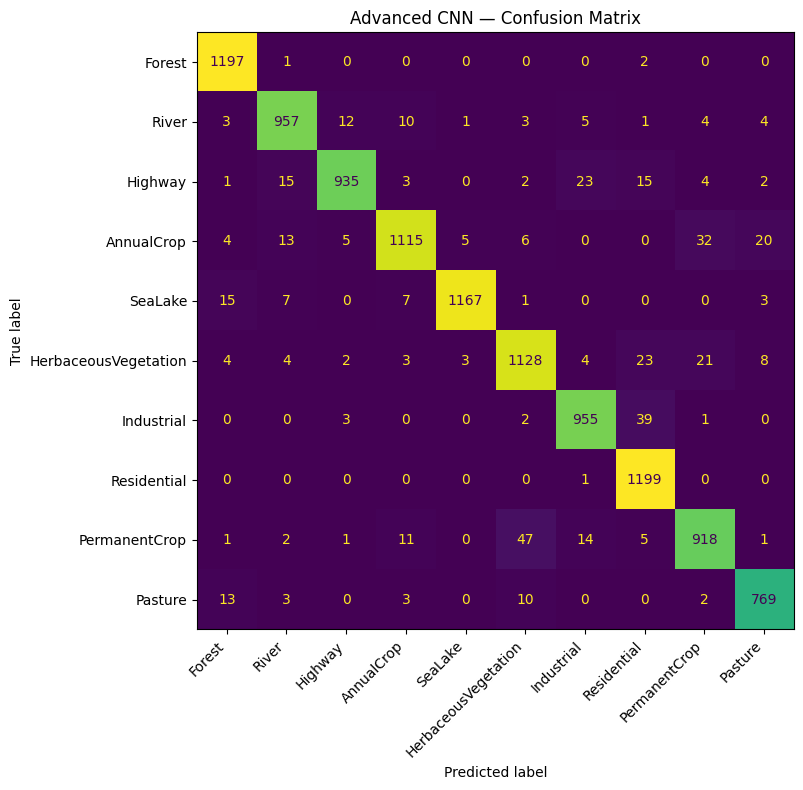

                      precision    recall  f1-score   support

              Forest       0.97      1.00      0.98      1200
               River       0.96      0.96      0.96      1000
             Highway       0.98      0.94      0.96      1000
          AnnualCrop       0.97      0.93      0.95      1200
             SeaLake       0.99      0.97      0.98      1200
HerbaceousVegetation       0.94      0.94      0.94      1200
          Industrial       0.95      0.95      0.95      1000
         Residential       0.93      1.00      0.97      1200
       PermanentCrop       0.93      0.92      0.93      1000
             Pasture       0.95      0.96      0.96       800

            accuracy                           0.96     10800
           macro avg       0.96      0.96      0.96     10800
        weighted avg       0.96      0.96      0.96     10800



In [84]:
# Two classes with highest error — confusion matrix + classification report
y_pred_advanced = np.argmax(model_advanced.predict(x_cnn_test), axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_advanced,
    display_labels=class_names,
    ax=ax, colorbar=False
)
ax.set_title("Advanced CNN — Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_advanced, target_names=class_names))

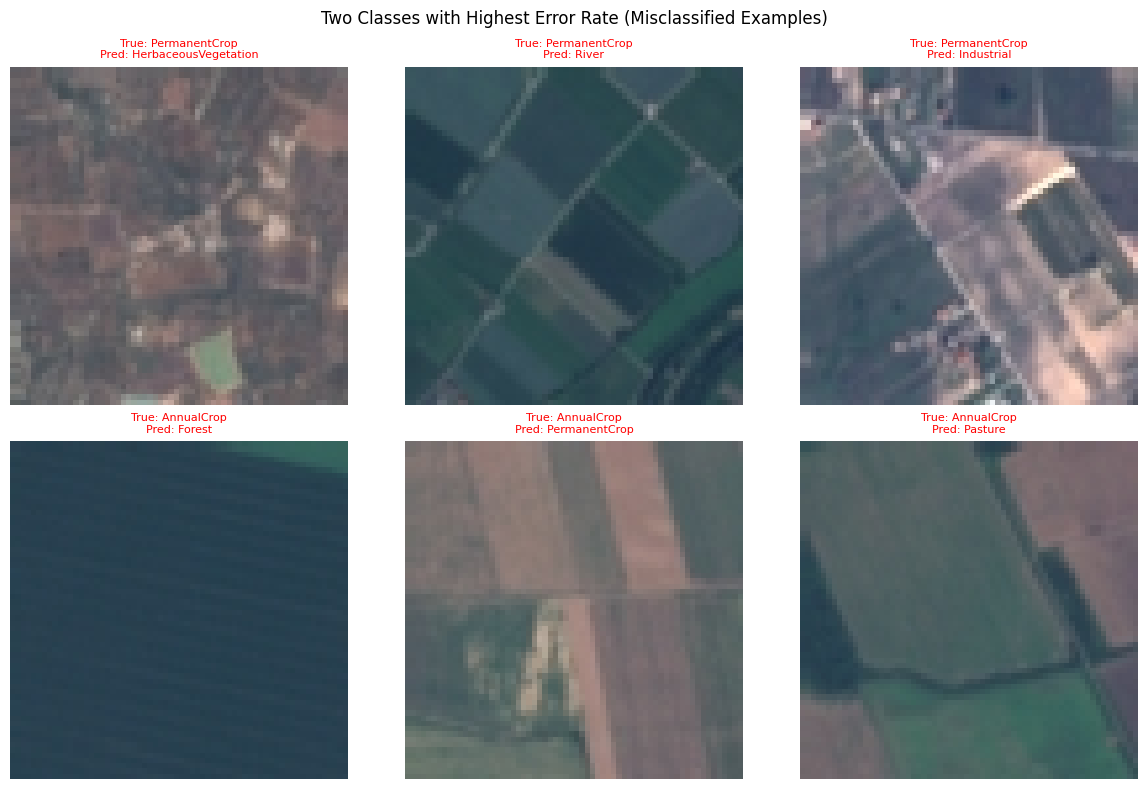

In [87]:
# Identify two worst classes by recall and show misclassified examples
report = classification_report(y_test, y_pred_advanced, target_names=class_names, output_dict=True)
sorted_classes = sorted(class_names, key=lambda c: report[c]["recall"])
top2 = sorted_classes[:2]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, class_name in enumerate(top2):
    label = class_names.index(class_name)
    mis_idx = np.where((y_test == label) & (y_pred_advanced != label))[0][:3]
    for col, idx in enumerate(mis_idx):
        axes[row, col].imshow(x_test_img[idx])
        axes[row, col].set_title(
            f"True: {class_name}\nPred: {class_names[y_pred_advanced[idx]]}",
            fontsize=8, color="red"
        )
        axes[row, col].axis("off")

plt.suptitle("Two Classes with Highest Error Rate (Misclassified Examples)")
plt.tight_layout()
plt.show()

The advanced model hit 95.74% accuracy, a +10.9% improvement over the baseline CNN (84.85%). It uses the same three-block convolutional structure but adds two techniques from the week10 lab: Batch Normalization after each convolutional and dense layer, which stabilizes training and allow faster convergence, and data augmentation via ImageDataGenerator (rotations, shifts, flips, zoom), which reduces overfitting by exposing the model to varied versions of each image each epoch.                                                                                                         

Training was further guided by ReduceLROnPlateau, which halved the learning rate four times as the validation loss plateaued, allowing finer optimization in later epochs. This is visible in the steady accuracy climb from ~91% at epoch 12 to 95.7% by epoch 40. 


### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.



## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?


# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning
## Submitted by: Joey Cahill, Sujan Kakumanu, Angel Rutherford

In this assignment, you will explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches. You will work with the EuroSAT dataset to implement and evaluate various classification models, from simple SVMs to complex deep learning architectures.

## Submission Guidelines

**All assignments must be completed in groups of 2-3 students.** One member of the group should submit on behalf of everyone, making sure to include all group members' names at the top of the notebook.

Your assignment should be submitted via a pull request to the main branch of this repository. Please make sure it is in the `assignments` subdirectory, titled `eurosat.ipynb`, with any additional files included in a subfolder named `eurosat_files`. Additionally:
- Your notebook must contain the complete assignment instructions, followed by the relevant code chunks
- Your notebook must include group members' names and submission date
- All code must be well-formatted with appropriate code chunks (no overly long code blocks)
- All code must be linted and formatted using [`ruff`](https://docs.astral.sh/ruff/) before submission

## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

Visit [the EuroSAT data description page](https://github.com/phelber/eurosat) and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.

## 2. Traditional Machine Learning

For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.

### 2.1 Binary Support Vector Machine

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.

## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

### 3.1 Greyscale Images

For this section, use the same greyscale images that you used in the traditional machine learning section.

#### 3.1.1 Single-Layer Neural Network

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

#### 3.1.2 Two-Layer Neural Network

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

#### 3.1.3 Four-Layer Neural Network with Dropout

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

#### 3.1.4 Model Comparison and Ensemble

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

### 3.2 RGB Images

For this section, use the original RGB images.

#### 3.2.1 CNN Model

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

#### 3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.

## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?

## 5. Rubric (10 points)

| Category                           | Weight | Excellent                                                            | Satisfactory                                   | Unsatisfactory                          |
| ---------------------------------- | ------ | -------------------------------------------------------------------- | ---------------------------------------------- | --------------------------------------- |
| **Analysis & Reflection (60%)**    |
| Model Analysis                     | 2.0    | Deep insights into model behavior; clear understanding of trade-offs | Basic analysis of model performance            | Superficial or missing analysis         |
| Comparative Analysis               | 2.0    | Thorough comparison of approaches; clear rationale for choices       | Basic comparison of models                     | Limited or missing comparisons          |
| Reflection & Future Work           | 2.0    | Thoughtful reflection; clear future directions; learning insights    | Basic reflection with some future ideas        | Superficial or missing reflection       |
| **Technical Implementation (40%)** |
| Data Processing                    | 1.0    | Clean, efficient implementation; thorough preprocessing              | Adequate implementation with minor issues      | Incomplete or flawed implementation     |
| Model Implementation               | 1.0    | Well-structured code; clear architecture; proper documentation       | Functional implementation with basic structure | Poor implementation or missing elements |
| Results & Visualization            | 1.0    | Professional visualizations; clear presentation of results           | Adequate visualizations with minor issues      | Poor or missing visualizations          |
| Code Documentation                 | 1.0    | Clear comments; well-organized; follows best practices               | Basic documentation with minor issues          | Poor or missing documentation           |
